# MLP for 5G-NIDD Dataset (Google Colab)
This notebook demonstrates an anomaly detection pipeline using an MLP neural network model on the 5G-NIDD dataset.

In [1]:
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')

# Path to your CSV in Drive
file_path = '/content/drive/MyDrive/Combined.csv'

# Read the CSV
data = pd.read_csv(file_path)

# Display first few rows
data.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_33172/3769801323.py:11: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(file_path)


,Unnamed: 0,Seq,Dur,RunTime,Mean,Sum,Min,Max,Proto,sTos,...,sVid,dVid,SrcTCPBase,DstTCPBase,TcpRtt,SynAck,AckDat,Label,Attack Type,Attack Tool
0,0,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,icmp,0.0,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,Benign,Benign,Benign
1,1,2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,icmp,0.0,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,Benign,Benign,Benign
2,2,3,4.998020,4.998020,4.998020,4.998020,4.998020,4.998020,udp,0.0,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,Benign,Benign,Benign
3,3,4,4.998037,4.998037,4.998037,4.998037,4.998037,4.998037,udp,0.0,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,Benign,Benign,Benign
4,4,5,4.999453,4.999453,4.999453,4.999453,4.999453,4.999453,udp,0.0,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,Benign,Benign,Benign


In [2]:
!pip install -U tensorflow scikit-learn==1.4.2 scikeras matplotlib seaborn
!pip install river

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.feature_selection import f_classif, SelectKBest
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Lambda
from scikeras.wrappers import KerasClassifier
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam, RMSprop
import tensorflow as tf

In [4]:
# Handle missing values
for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = data[col].fillna(data[col].mode()[0])
    else:
        data[col] = data[col].fillna(data[col].median())

# Encode categorical columns
data = pd.get_dummies(data, columns=['Proto', 'State','Cause','sDSb','dDSb'], drop_first=True)

In [5]:
data['binary_label'] = data['Label'].apply(lambda x: 0 if x == 'Benign' else 1)

In [6]:
print(data['binary_label'].value_counts())

binary_label
1    738153
0    477737
Name: count, dtype: int64


In [7]:
X=data.drop(['Label','binary_label','Attack Type', 'Attack Tool','Unnamed: 0'],axis=1,errors='ignore')
y=data['binary_label']



In [8]:
#train/test/validate
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=1/9, stratify=y_temp, random_state=42
)

In [9]:
# Compute ANOVA F-score
f_scores, p_values = f_classif(X, y)

# Create a readable table
anova_results = pd.DataFrame({
    "Feature": X.columns,
    "F-Score": f_scores,
    "P-Value": p_values
})

anova_results = anova_results.sort_values(by="F-Score", ascending=False)
print("ANOVA selected features:", anova_results)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [36 37] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


ANOVA selected features:       Feature        F-Score   P-Value
0         Seq  469849.639067  0.000000
19     Offset  319314.409720  0.000000
9        sTtl  271783.716581  0.000000
48  Proto_tcp  203833.922817  0.000000
42     AckDat  114843.308858  0.000000
..        ...            ...       ...
64    sDSb_54       1.545104  0.213860
76   dDSb_cs4       1.545104  0.213860
30     DstGap       0.900303  0.342701
36       sVid            NaN       NaN
37       dVid            NaN       NaN

[78 rows x 3 columns]


In [11]:
#Apply ANOVA to Select TOP 10 Features
selector = SelectKBest(score_func=f_classif, k=10)

X_train = selector.fit_transform(X_train, y_train)
X_val = selector.transform(X_val)
X_test = selector.transform(X_test)

#Get the Names of Selected Features
selected_indices = selector.get_support(indices=True)
top_10_features = X.columns[selected_indices]

print(" Top 10 Features from ANOVA:")
print(top_10_features)


 Top 10 Features from ANOVA:
Index(['Seq', 'Dur', 'RunTime', 'Mean', 'Sum', 'Min', 'Max', 'sTos', 'dTos',
       'sTtl'],
      dtype='object')


In [12]:
X = X[top_10_features]


In [13]:
anova_scores = pd.DataFrame({
    "Feature": X.columns,
    "F_Score": selector.scores_[selected_indices],
    "p_value": selector.pvalues_[selected_indices]
})

anova_scores = anova_scores.sort_values(by="F_Score", ascending=False)
print(anova_scores.head(10))

   Feature        F_Score  p_value
0      Seq  374083.236109      0.0
2  RunTime  254147.328667      0.0
1      Dur  218128.605366      0.0
6      Max  163015.377147      0.0
4      Sum   92290.225981      0.0
7     sTos   88582.314549      0.0
9     sTtl   40566.113937      0.0
8     dTos   39138.312306      0.0
3     Mean   38160.831585      0.0
5      Min   33803.932919      0.0


In [15]:
#train/test/validate
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=1/9, stratify=y_temp, random_state=42
)

In [16]:
#balance and scale for tuning
df_train = pd.concat([X_train, y_train], axis=1)
benign = df_train[df_train['binary_label'] == 0]
attack = df_train[df_train['binary_label'] == 1]

# Downsample the majority class
if len(benign) > len(attack):
    benign_down = resample(benign,
                           replace=False,
                           n_samples=len(attack),
                           random_state=42)
    df_bal = pd.concat([benign_down, attack])
else:
    attack_down = resample(attack,
                           replace=False,
                           n_samples=len(benign),
                           random_state=42)
    df_bal = pd.concat([benign, attack_down])


# Split features and labels
X_bal = df_bal.drop('binary_label', axis=1)
y_bal = df_bal['binary_label']

#Normalize
scaler = StandardScaler()
X_bal = scaler.fit_transform(X_bal)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [17]:
#Build VAE
from tensorflow.keras import layers, Model

input_dim = X_bal.shape[1]
latent_dim = 10

encoder_inputs = layers.Input(shape=(input_dim,))
x = layers.Dense(32, activation="relu")(encoder_inputs)

z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)

class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = Sampling()([z_mean, z_log_var])

encoder = tf.keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

latent_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(32, activation="relu")(latent_inputs)
decoder_outputs = layers.Dense(input_dim)(x)

decoder = tf.keras.Model(latent_inputs, decoder_outputs, name="decoder")

In [18]:
#VAE loss
import tensorflow as tf

class VAE(tf.keras.Model):

    def __init__(self, encoder, decoder):
        super(VAE, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        return reconstruction

    def train_step(self, data):

        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:

            z_mean, z_log_var, z = self.encoder(data)

            reconstruction = self.decoder(z)

            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(tf.square(data - reconstruction), axis=1)
            )

            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                    axis=1
                )
            )

            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)

        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        return {
            "loss": total_loss,
            "reconstruction_loss": reconstruction_loss,
            "kl_loss": kl_loss
        }

In [19]:
#compile model
vae = VAE(encoder, decoder)

vae.compile(optimizer=tf.keras.optimizers.Adam(), loss="mse")

In [20]:
#Train VAE
vae.fit(
    X_bal,
    epochs=30,
    batch_size=128,
    validation_data=(X_val, X_val), # Changed validation_data from (X_val, None) to (X_val, X_val)
    verbose=1
)

Epoch 1/30
5972/5972 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - kl_loss: 2.1289 - loss: 3.1341 - reconstruction_loss: 1.0052 - val_loss: 0.0842
Epoch 2/30
5972/5972 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - kl_loss: 1.8906 - loss: 2.8696 - reconstruction_loss: 0.9789 - val_loss: 0.0791
Epoch 3/30
5972/5972 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - kl_loss: 1.8188 - loss: 2.3953 - reconstruction_loss: 0.5765 - val_loss: 0.0709
Epoch 4/30
5972/5972 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - kl_loss: 1.8402 - loss: 2.4200 - reconstruction_loss: 0.5799 - val_loss: 0.0702
Epoch 5/30
5972/5972 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - kl_loss: 2.1697 - loss: 3.2421 - reconstruction_loss: 1.0724 - val_loss: 0.0712
Epoch 6/30
5972/5972 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - kl_loss: 1.6822 - loss: 2.2516 - reconstruction_loss: 0.5694 - val_loss: 0.0707
Epoch 7/30
5972/5972 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - kl_loss: 1.6452 - loss: 2.1558 - reconstruction_loss: 0.5106 - val_loss: 0.0704
Epoch 8/30
5972/5972 ━━━━━━━━━━━━━━━━━━━━

In [22]:
#Extract latent features
z_mean, _, _ = encoder.predict(X_bal)
X_train_latent = z_mean

z_mean, _, _ = encoder.predict(X_val)
X_val_latent = z_mean

z_mean, _, _ = encoder.predict(X_test)
X_test_latent = z_mean

23887/23887 ━━━━━━━━━━━━━━━━━━━━ 53s 2ms/step
3800/3800 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
3800/3800 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step


In [24]:
#Train XGBoost Classifier

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8
)

xgb_model.fit(X_train_latent, y_bal)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [25]:
from collections import deque
from river.drift import ADWIN
# Sliding window to store recent prediction probabilities
# This window helps compute adaptive thresholds
prob_window = deque(maxlen=1500)

# Minimum samples before adaptive threshold starts
MIN_SAMPLES_BEFORE_ADAPT = 30

# Quantile used for adaptive threshold
QUANTILE = 0.9

SMOOTHING_ALPHA = 0.9
COOLDOWN = 200 #prevent frequent retraining


threshold_history = []

# Initialize ADWIN drift detector
# ADWIN monitors prediction error and detects statistical changes
drift_detector = ADWIN()

# List to store drift detection points
drift_points = []

# Store predicted probabilities for analysis
y_probs_all = []

last_drift_index = -COOLDOWN

In [26]:
#adaptive threshold function
# Instead of using a fixed threshold (0.5), the model dynamically
# adjusts the threshold based on recent prediction probabilities
def adaptive_threshold(prob_window, default=0.5):

    if len(prob_window) < MIN_SAMPLES_BEFORE_ADAPT:
        return default

    window = np.array(prob_window)

    mean = np.mean(window)
    std = np.std(window)

    if std < 1e-6:  # avoid instability
        return default

    # normalize probabilities
    normalized = (window - mean) / std

    # compute quantile in normalized space
    q_val = np.quantile(normalized, QUANTILE)

    # convert back to probability scale
    threshold = mean + q_val * std

    # safe limits
    threshold = np.clip(threshold, 0.3, 0.7)

    return float(threshold)



In [27]:
# For binary classification, take probability of class 1 (Attack)
y_probs = xgb_model.predict_proba(X_test_latent)[:, 1]

#adaptive prediction loop
adaptive_predictions = []

y_test_np = y_test.values

# Store recent stream samples (for retraining)
X_stream_buffer = []
y_stream_buffer = []

for i, prob in enumerate(y_probs):

    # Store predicted probability
    y_probs_all.append(prob)

    # Add probability to sliding window
    prob_window.append(prob)

    # Compute adaptive threshold
    threshold = adaptive_threshold(prob_window)

    # smoothing
    if len(threshold_history) > 0:
        threshold = SMOOTHING_ALPHA * threshold_history[-1] + (1 - SMOOTHING_ALPHA) * threshold

    threshold_history.append(threshold)

    # Convert probability to predicted class
    pred = 1 if prob > threshold else 0
    adaptive_predictions.append(pred)

    # Store stream sample
    X_stream_buffer.append(X_test_latent[i])
    y_stream_buffer.append(y_test_np[i])

    # Calculate prediction error: 0 = correct prediction, 1 = incorrect prediction
    error = int(pred != y_test_np[i])

    # Update drift detector
    drift_detector.update(error)

    if drift_detector.drift_detected and (i - last_drift_index > COOLDOWN):

        print(f"Drift detected at sample {i}")
        drift_points.append(i)
        last_drift_index = i

        # Use recent stream data
        if len(X_stream_buffer) > 200:

            X_recent = np.array(X_stream_buffer[-500:])
            y_recent = np.array(y_stream_buffer[-500:])

            print("Retraining model on recent stream data...")

            xgb_model.fit(X_recent, y_recent)

        # Reset buffers
        prob_window.clear()
        X_stream_buffer = []
        y_stream_buffer = []


 Test Set Results:
Adaptive Accuracy: 0.9935438238656458

Adaptive Classification Report:
              precision    recall  f1-score   support

      Benign   0.988380  0.995269  0.991813     47774
      Attack   0.996924  0.992427  0.994671     73815

    accuracy                       0.993544    121589
   macro avg   0.992652  0.993848  0.993242    121589
weighted avg   0.993567  0.993544  0.993548    121589



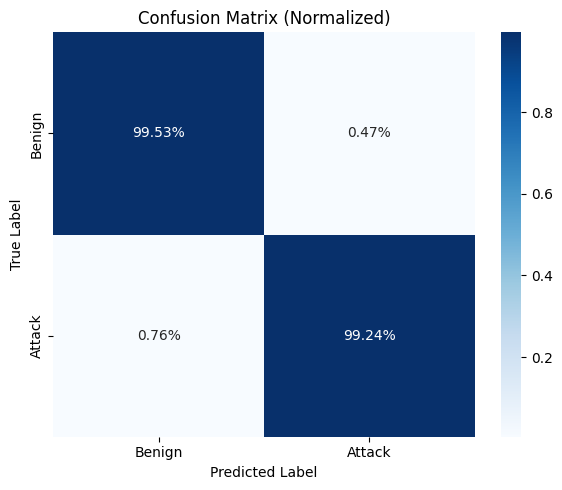

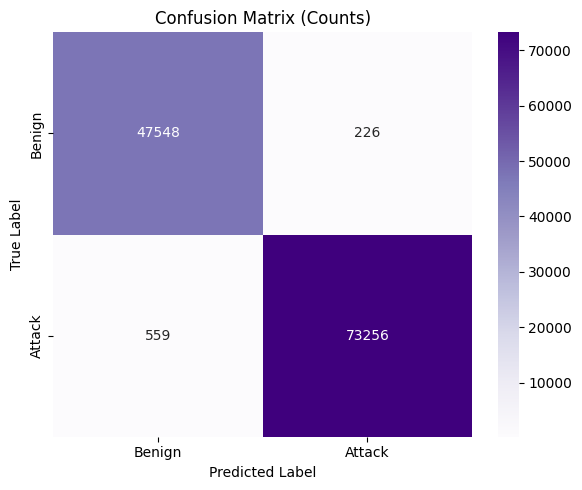

In [28]:
print("\n Test Set Results:")
print("Adaptive Accuracy:", accuracy_score(y_test_np, adaptive_predictions))
print("\nAdaptive Classification Report:")
print(classification_report(y_test_np, adaptive_predictions, target_names=['Benign', 'Attack'],digits=6))


cm = confusion_matrix(y_test_np, adaptive_predictions)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(6, 5))
sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Blues",
            xticklabels=['Benign', 'Attack'],
            yticklabels=['Benign', 'Attack'])
plt.title("Confusion Matrix (Normalized)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# Raw counts confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=['Benign', 'Attack'],
            yticklabels=['Benign', 'Attack'])
plt.title("Confusion Matrix (Counts)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()